In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#1
siniestros = stats.poisson.rvs(mu=500, size=10000)
costos_totales =[]

for n in siniestros:
    costos = stats.lognorm.rvs(s=1.2, scale=np.exp(8.5), size=n)
    costos_año = np.sum(costos)
    costos_totales.append(costos_año)

In [2]:
#2
S_array = np.array(costos_totales)
costo_promedio = S_array.mean()
print(costo_promedio)

5045721.306495973


In [3]:
#3
VaR_99 = np.percentile(S_array,99)
print(VaR_99)

6246656.750132286


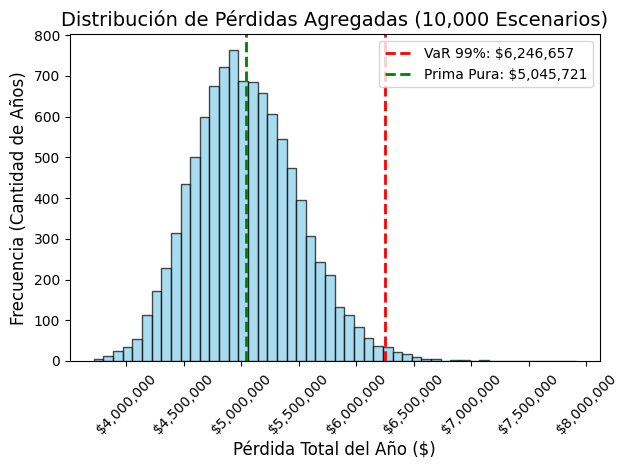

In [4]:
#4
'''
Si quiero pasarlo a DataFrame, pero no es necesario
df = pd.DataFrame({
    'Siniestros':siniestros,
    'Costo_Total':S_array})
'''
plt.hist(S_array, bins=50, color='skyblue', edgecolor='black',alpha=0.7)
plt.axvline(VaR_99, color='red',linestyle='dashed', linewidth=2, label=f'VaR 99%: ${VaR_99:,.0f}')

# (Opcional) Podemos agregar también la línea de la Prima Pura Promedio
Prima_Pura = np.mean(S_array)
plt.axvline(Prima_Pura, color='green', linestyle='dashed', linewidth=2, label=f'Prima Pura: ${Prima_Pura:,.0f}')

# Estética Profesional: Títulos y Etiquetas
plt.title('Distribución de Pérdidas Agregadas (10,000 Escenarios)', fontsize=14)
plt.xlabel('Pérdida Total del Año ($)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Años)', fontsize=12)

# Forzar que los saltos (ticks) del eje X sean estrictamente de a 500,000
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(500000))

# Dar formato de moneda con separador de miles y ELIMINAR el 1e6
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Rotar las etiquetas del eje X a 45 grados (diagonal)
plt.xticks(rotation=45)

# Ajustar los márgenes automáticamente para que las etiquetas no se corten por debajo
plt.tight_layout()

# Mostrar la leyenda (para que se vean los valores exactos del VaR) y mostrar el gráfico
plt.legend()
plt.savefig('distribucion_riesgo_montecarlo.png', dpi=300, bbox_inches='tight')
plt.show()